# An attempt to construct a variational autoencoder(based on Troels´ autoencoder example)

In [31]:
import matplotlib as mpl
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd 
import random 

from torch.utils.data import Dataset, DataLoader
import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from torch import nn
import torch.nn.functional as F
import torch.optim as optim

from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from os import listdir
from os.path import isfile, join
import pandas as pd
import os
import numpy as np
import umap
from sklearn.datasets import fetch_openml
import seaborn as sns
from sklearn import preprocessing
from sklearn import cluster
from sklearn import manifold
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
import itertools

### Data loading

In [32]:
#Getting the images:
unique_path = r"../data\grand_scraper_folder\unique_scrandle_cases_FULL.csv"
unique_dataframe = pd.read_csv(unique_path)
unique_entries = [unique_dataframe["occurrences"][i].split("|")[0].split(" ")[0] + ".webp" for i in range(len(unique_dataframe["occurrences"]))]

#Next, we´ll get the low-res photos imported(doesnt take long. for my computer: 7.5s)

#Creating a list for the photos with the corresponding dates and image names as well(crude way of being able to see which are outliers.
#Needs to be done better, really. If someone has the time, feel free to find a better way of doing things)
image_Data_low_res = []




#Folder with folders of images:
base_folder = r"../data\scrandle_padded_low_res_data"

current_folder = None


#Looping over all dates in the listed directory/folder:
for entry in sorted(unique_entries):
    date, image_placement = entry.split(":")
    
    #Finding a new date folder to check
    date_path = os.path.join(base_folder, date)
    #Checking if the date path exists
    if not os.path.isdir(date_path):
        continue

    print(f"Processing {entry}")
    
    #Reading entry image:
    image_path = os.path.join(date_path, image_placement)
    image_Data_low_res.append({
                    "date": date,
                    "image_name": image_placement,
                    "RGB": plt.imread(image_path, format="webp"),
                })

Processing 2025-04-20:0_left.webp
Processing 2025-04-20:0_right.webp
Processing 2025-04-20:1_left.webp
Processing 2025-04-20:1_right.webp
Processing 2025-04-20:2_left.webp
Processing 2025-04-20:2_right.webp
Processing 2025-04-20:3_left.webp
Processing 2025-04-20:3_right.webp
Processing 2025-04-20:4_left.webp
Processing 2025-04-20:4_right.webp
Processing 2025-04-20:5_left.webp
Processing 2025-04-20:5_right.webp
Processing 2025-04-20:6_left.webp
Processing 2025-04-20:6_right.webp
Processing 2025-04-20:7_left.webp
Processing 2025-04-20:7_right.webp
Processing 2025-04-20:8_left.webp
Processing 2025-04-20:8_right.webp
Processing 2025-04-20:9_left.webp
Processing 2025-04-20:9_right.webp
Processing 2025-04-21:0_left.webp
Processing 2025-04-21:0_right.webp
Processing 2025-04-21:1_left.webp
Processing 2025-04-21:1_right.webp
Processing 2025-04-21:2_left.webp
Processing 2025-04-21:2_right.webp
Processing 2025-04-21:3_left.webp
Processing 2025-04-21:3_right.webp
Processing 2025-04-21:4_left.webp


In [38]:
#Getting only the images:
image_only_low_res = []
for i in range(len(image_Data_low_res)):
    image_only_low_res.append(image_Data_low_res[i]["RGB"])

image_train = torch.from_numpy(np.array(image_only_low_res[:1000])/255).permute(0,3,1,2).float()
image_test = torch.from_numpy(np.array(image_only_low_res[1000:1500])/255).permute(0,3,1,2).float()

In [39]:
#Next, for the dataloader:
class ImageDataset(Dataset):
    def __init__(self, images):
        
        self.images = images

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]

        return image

dataset_train = ImageDataset(image_train)
dataset_test = ImageDataset(image_test)
loader_train = DataLoader(dataset_train, batch_size=1, shuffle=True)
loader_test = DataLoader(dataset_test, batch_size=1, shuffle=True)

### Model(Adapted from Troels autoencoder example solution)

In [ ]:
class Encoder(nn.Module):
    
    def __init__(self, encoded_space_dim,fc2_input_dim):
        super().__init__()
        
        ### Convolutional section:
        # So we decide to take our 1 input image and first apply 8 kernels/filters of size 3x3
        # with a stride (i.e. step size) of 2 and padding the edge with one layer.
        # This output goes through a ReLU and then through 16 new kernels/filters
        # of the same size, stride and padding, which is then BatchNorm'ed, ReLU'ed, and finally
        # convoluted a third time, again doubling the number of kernels/filters (quite standard!).
        self.encoder_cnn = nn.Sequential(
            nn.Conv2d(3, 8, 3, stride=2, padding=0),
            nn.ReLU(True),
            nn.Conv2d(8, 16, 3, stride=2, padding=0),
            nn.BatchNorm2d(16),
            nn.ReLU(True),
            nn.Conv2d(16, 32, 3, stride=2, padding=0),
            nn.ReLU(True)
        )
        
        ### Flatten layer
        # The images/matrices are then flatten'ed (put into one long array), put through a linear layer,
        # then a ReLU, and then finally another linear layer, which boils it down to the latent space
        # dimension.
        self.flatten = nn.Flatten(start_dim=1)
        ### Linear section
        self.encoder_lin = nn.Sequential(
            nn.Linear(11*9*32, 128),
            nn.ReLU(True),
            nn.Linear(128, encoded_space_dim)
        )
        
    def forward(self, x):
        x = self.encoder_cnn(x)
        x = self.flatten(x)
        x = self.encoder_lin(x)
        return x
    
class Decoder(nn.Module):
    
    def __init__(self, encoded_space_dim,fc2_input_dim):
        super().__init__()
        self.decoder_lin = nn.Sequential(
            nn.Linear(encoded_space_dim, 128),
            nn.ReLU(True),
            nn.Linear(128, 11*9*32),
            nn.ReLU(True)
        )

        ### The decoder does the exact opposite, reconstructing the images from the latent space values.
        self.unflatten = nn.Unflatten(dim=1, 
        unflattened_size=(32, 11, 9))

        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, output_padding=0),
            nn.BatchNorm2d(16),
            nn.ReLU(True),
            nn.ConvTranspose2d(16, 8, 3, stride=2, padding=0, output_padding=0),
            nn.BatchNorm2d(8),
            nn.ReLU(True),
            nn.ConvTranspose2d(8, 3, 3, stride=2, padding=0, output_padding=0)
        )
        
    def forward(self, x):
        x = self.decoder_lin(x)
        x = self.unflatten(x)
        x = self.decoder_conv(x)
        x = torch.sigmoid(x)
        return x

In [121]:
# Define loss function and training parameters:

# Define the loss function
loss_fn = nn.MSELoss()

# Define an optimizer (both for the encoder and the decoder!)
lr = 0.001

# Set the random seed for reproducible results
torch.manual_seed(42)

# Initialize the two networks
d = 4
encoder = Encoder(encoded_space_dim=d, fc2_input_dim=128)
decoder = Decoder(encoded_space_dim=d, fc2_input_dim=128)
params_to_optimize = [
    {'params': encoder.parameters()},
    {'params': decoder.parameters()}
]

optim = torch.optim.Adam(params_to_optimize, lr=lr, weight_decay=1e-05)

In [122]:
# Define training and validation functions:

### Training function
def train_epoch(encoder, decoder, dataloader, loss_fn, optimizer):
    # Set train mode for both the encoder and the decoder
    encoder.train()
    decoder.train()
    train_loss = []
    # Iterate the dataloader (we do not need the label values, this is unsupervised learning)
    for image_batch in dataloader: # with "_" we just ignore the labels (the second element of the dataloader tuple)
        # Encode data
        encoded_data = encoder(image_batch)
        # Decode data
        decoded_data = decoder(encoded_data)
        test = decoded_data.detach().cpu().numpy()
        break
        # Evaluate loss
        loss = loss_fn(decoded_data, image_batch)
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # Print batch loss
#         print('\t partial train loss (single batch): %f' % (loss.data))
        train_loss.append(loss.detach().cpu().numpy())

    #return np.mean(train_loss)
    return test


### Testing function
def test_epoch(encoder, decoder, dataloader, loss_fn):
    # Set evaluation mode for encoder and decoder
    encoder.eval()
    decoder.eval()
    with torch.no_grad(): # No need to track the gradients
        # Define the lists to store the outputs for each batch
        conc_out = []
        conc_label = []
        for image_batch, _ in dataloader:
            # Encode data
            encoded_data = encoder(image_batch)
            # Decode data
            decoded_data = decoder(encoded_data)
            # Append the network output and the original image to the lists
            conc_out.append(decoded_data.cpu())
            conc_label.append(image_batch.cpu())
        # Create a single tensor with all the values in the lists
        conc_out = torch.cat(conc_out)
        conc_label = torch.cat(conc_label) 
        # Evaluate global loss
        val_loss = loss_fn(conc_out, conc_label)
    return val_loss.data

In [123]:
# Train the model
num_epochs = 1
diz_loss = {'train_loss':[],'val_loss':[]}
for epoch in range(num_epochs):
    train_loss = train_epoch(encoder,decoder, loader_train, loss_fn, optim)
    val_loss = test_epoch(encoder,decoder,loader_test,loss_fn)
    print('\n EPOCH {}/{} \t train loss {} \t val loss {}'.format(epoch + 1, num_epochs,train_loss,val_loss))
    diz_loss['train_loss'].append(train_loss)
    diz_loss['val_loss'].append(val_loss)

ValueError: not enough values to unpack (expected 2, got 1)

In [143]:
normal_image = np.int64(np.round(train_loss*255))

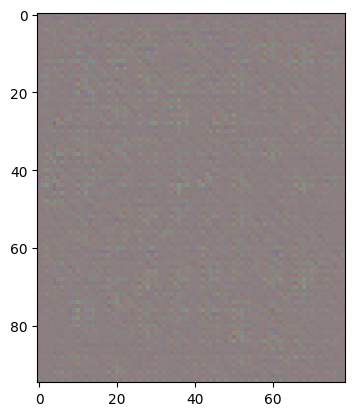

In [144]:
plt.imshow(normal_image[0].transpose(1, 2, 0))

In [142]:
np.int64(normal_image)

array([[[[139, 140, 137, ..., 135, 138, 136],
         [140, 138, 138, ..., 141, 136, 142],
         [134, 143, 138, ..., 130, 139, 145],
         ...,
         [138, 140, 135, ..., 135, 139, 139],
         [140, 141, 143, ..., 142, 140, 140],
         [138, 138, 137, ..., 137, 139, 139]],

        [[123, 126, 130, ..., 129, 129, 128],
         [123, 126, 127, ..., 123, 124, 124],
         [125, 122, 131, ..., 135, 125, 128],
         ...,
         [130, 127, 130, ..., 135, 126, 128],
         [126, 127, 124, ..., 129, 126, 126],
         [128, 127, 130, ..., 130, 127, 127]],

        [[128, 128, 128, ..., 131, 128, 125],
         [128, 129, 131, ..., 132, 128, 129],
         [130, 132, 126, ..., 125, 131, 126],
         ...,
         [130, 127, 129, ..., 129, 126, 131],
         [127, 129, 124, ..., 128, 128, 128],
         [129, 128, 131, ..., 131, 128, 128]]]], shape=(1, 3, 95, 79))

In [55]:
np.shape(test_stuff.numpy())

(1, 3, 100, 85)

In [63]:
9*32

288